Note: code snippets and content are on basis of a RAG course available on DataCamp. Also some notes are AI generated.


# Part 1: Building RAG applications with Langchain


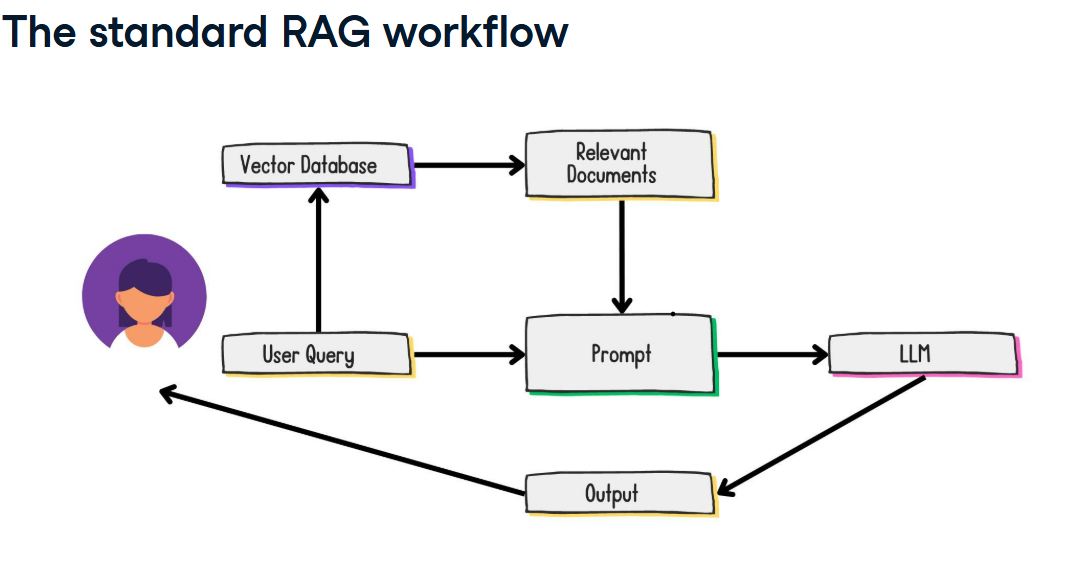

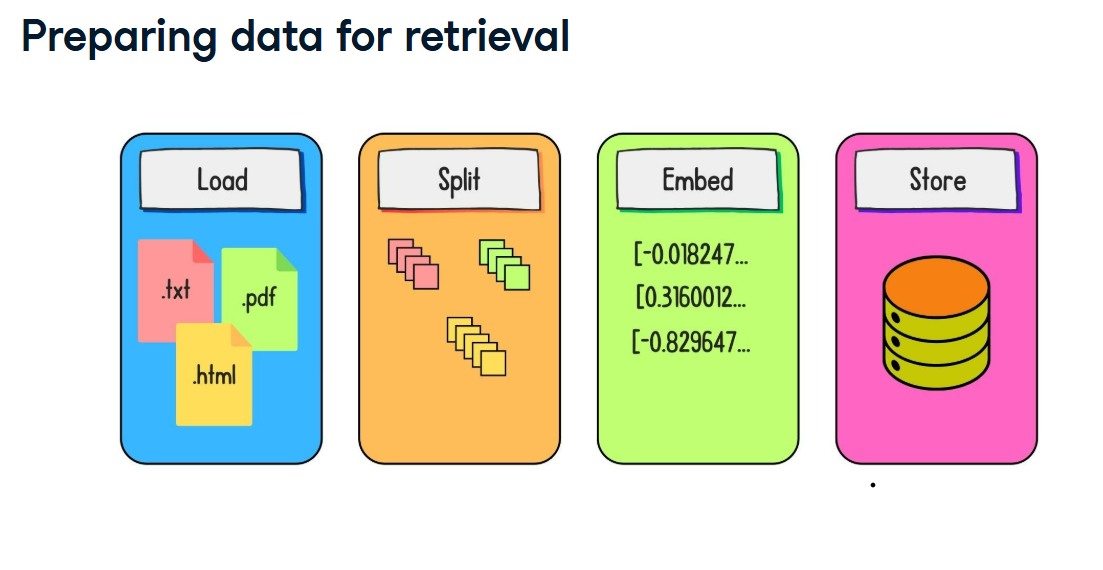

### Document loaders
LangChain document loaders facilitate the integration of documents into AI systems. These loaders handle various file types, including standard formats like CSV and PDFs, as well as specialized formats supported by third-party providers, such as Amazon S3 files, Jupyter notebooks, and audio transcripts. 
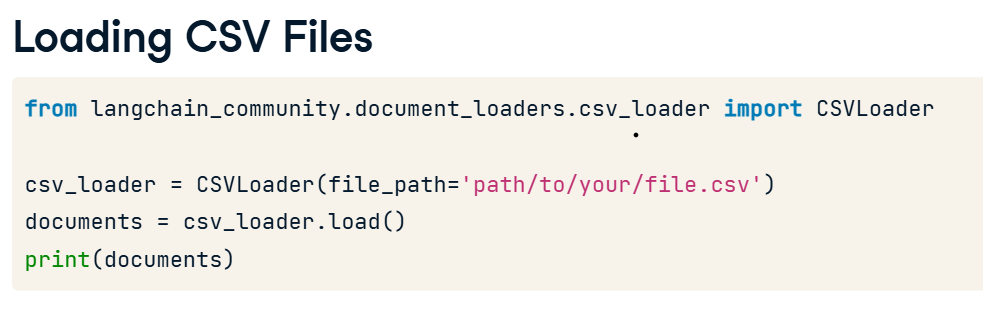

Likewise, we can use PyPDFLoader to load pdf files and UnstructuredHTMLLoader to load html files

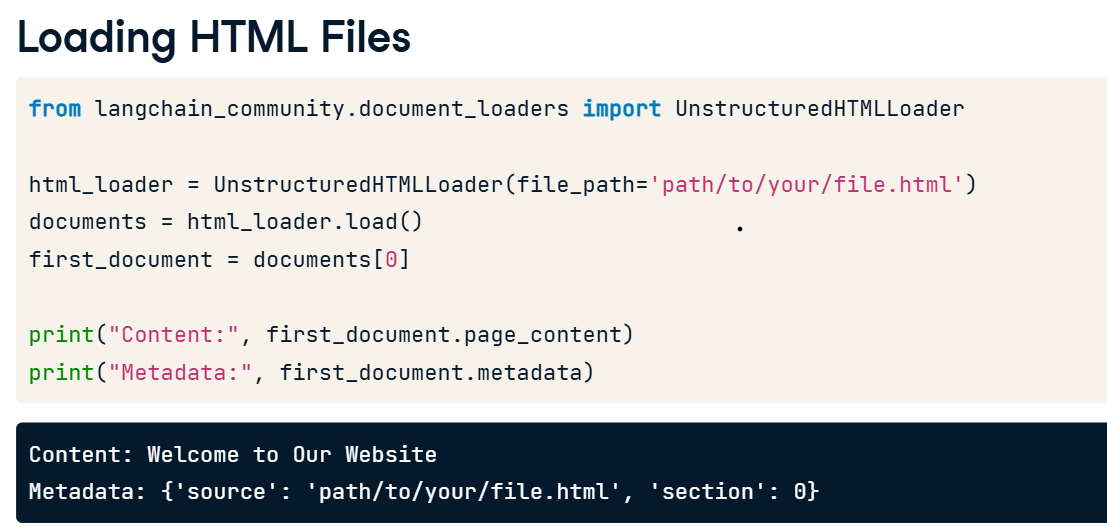

### Text splitting, embeddings and vector storage
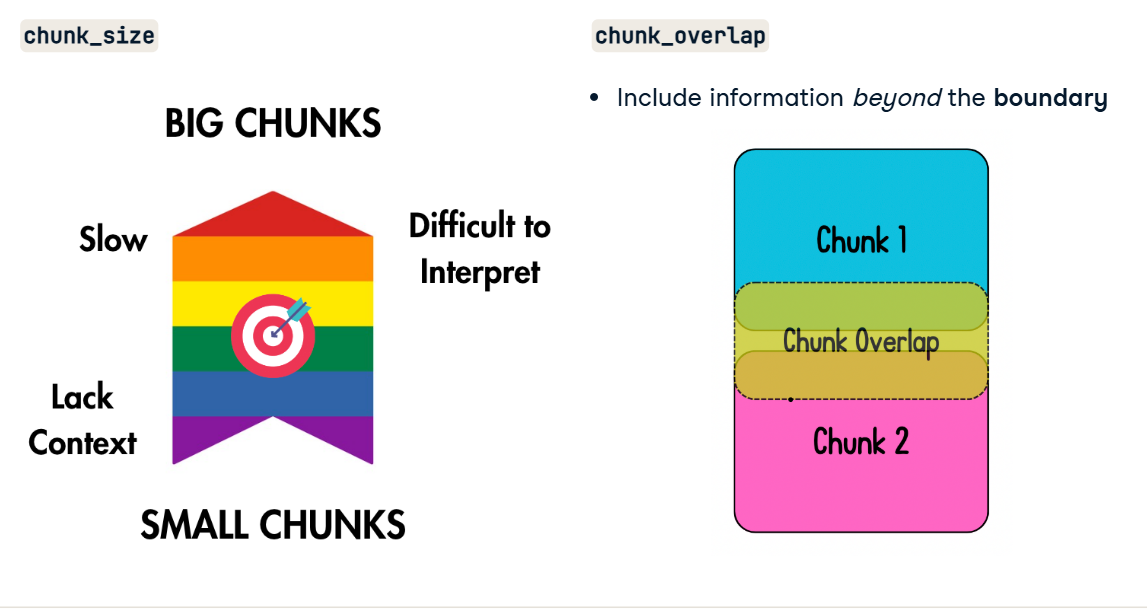

For text splitting, we can use CharacterTextSplitter and RecursiveCharacterTextSplitter.
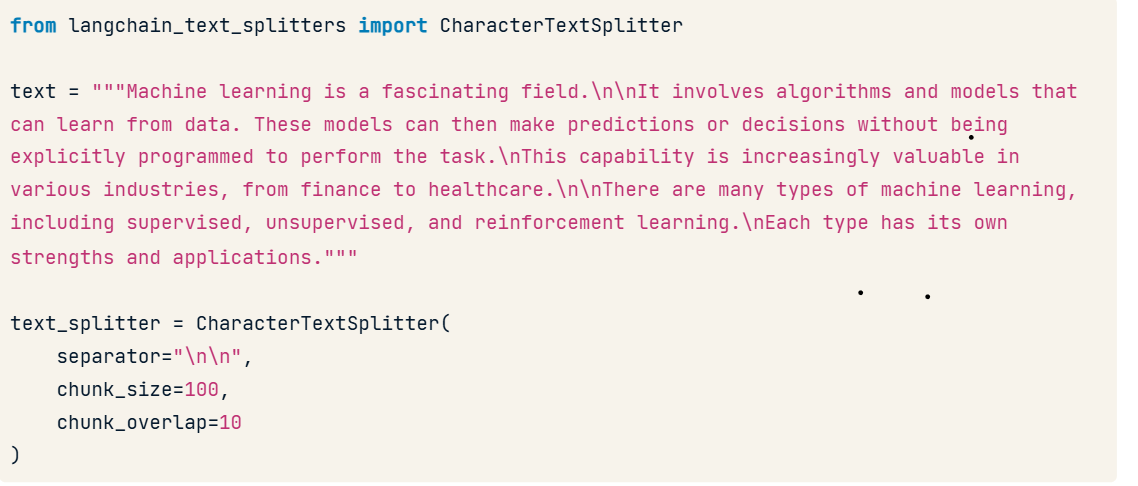
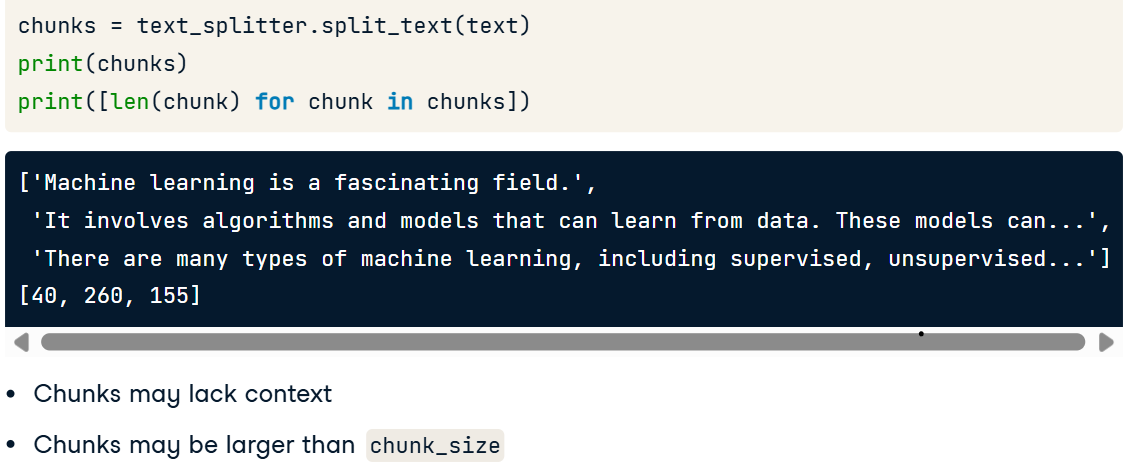

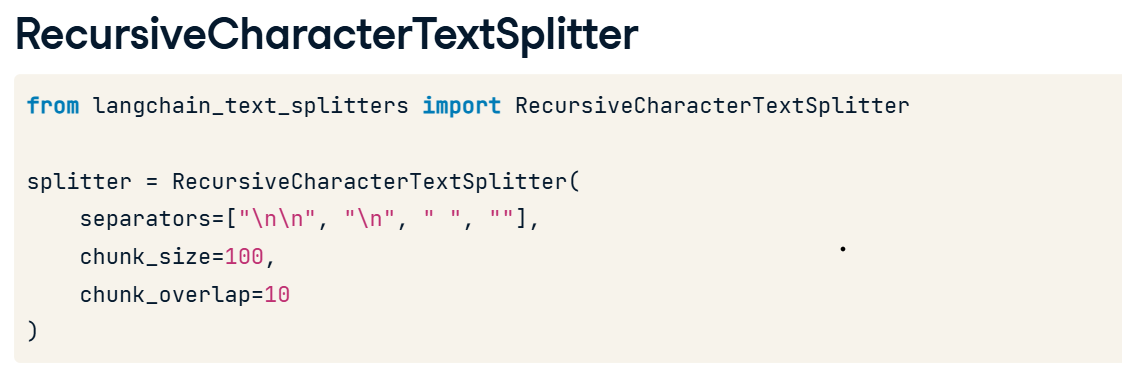
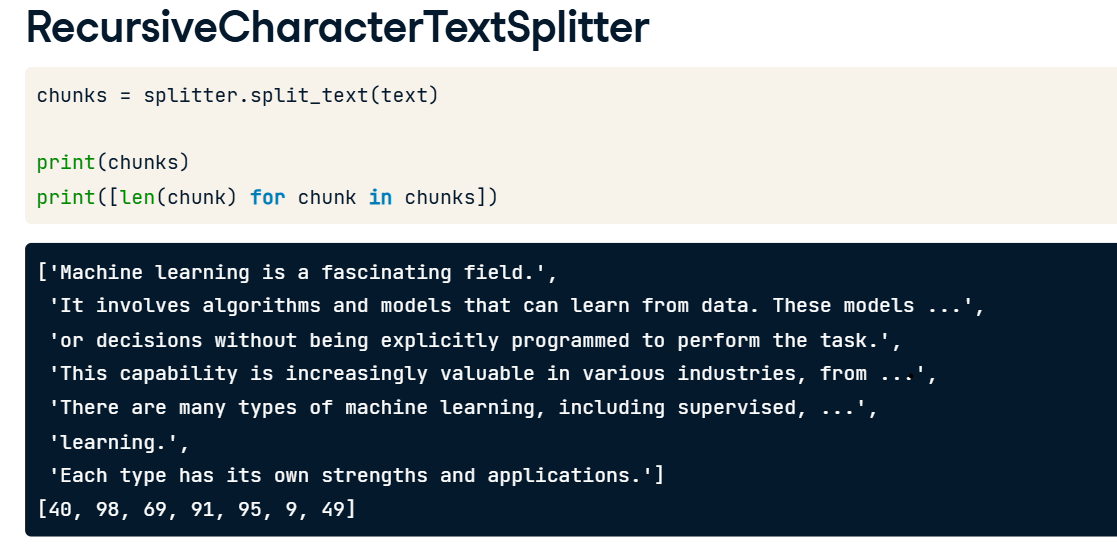

#### Also, to split the documents, we can load the documents and use split_documents() instead of split_text()

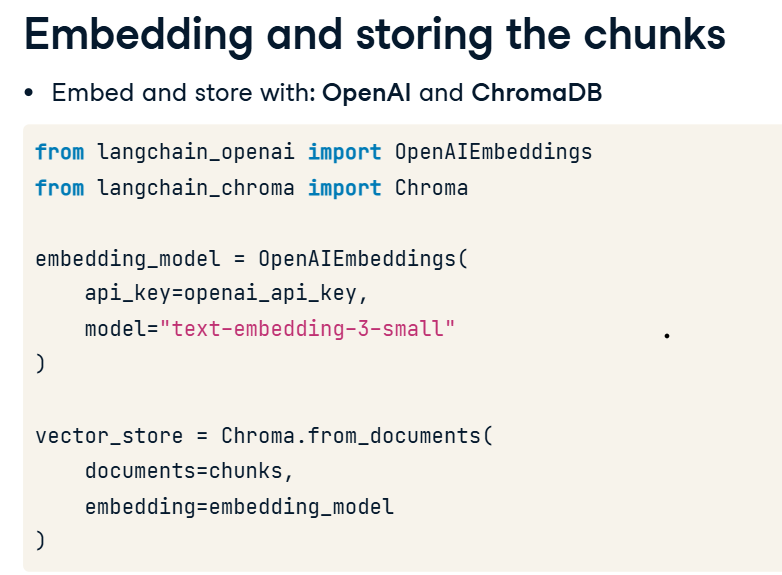


### Building an LCEL retrieval chain
LangChain Expression Language, or LCEL, is a declarative syntax for defining chains suited from prototypes to production. It is particularly relevant to RAG systems because it creates modular, reusable pipelines that can combine retrieval and generation components together. The retrieval chain will take a question input, insert it into the chain using RunnablePassthrough and assign it to "question". RunnablePassthrough allows inputs to be inserted into chains unchanged.

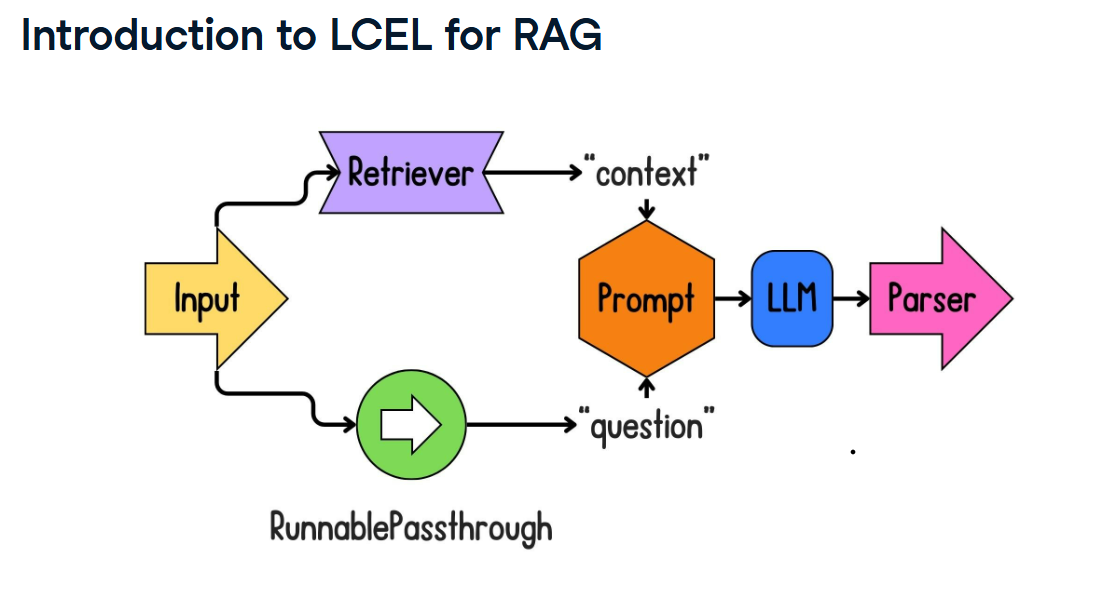
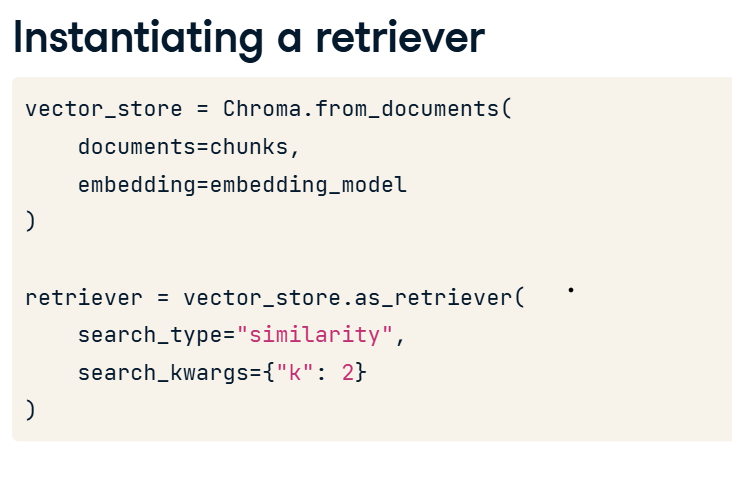
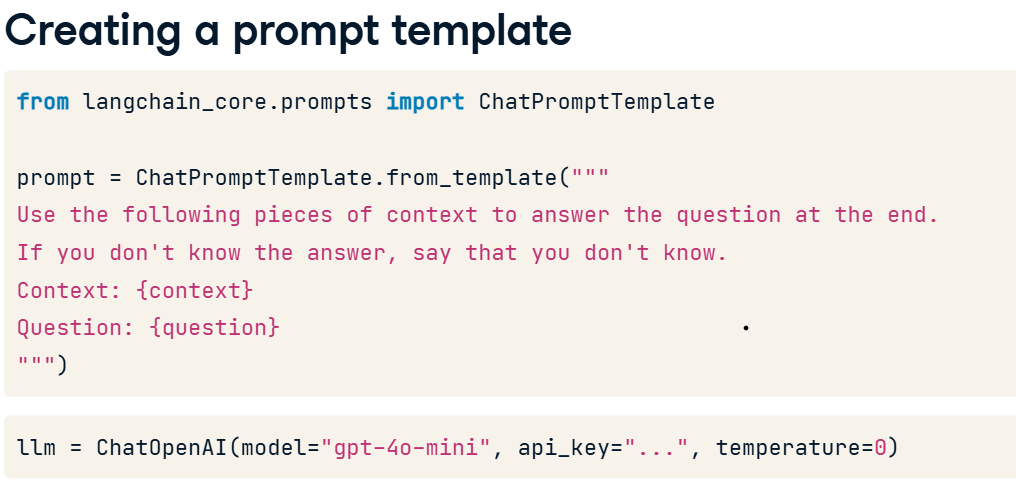
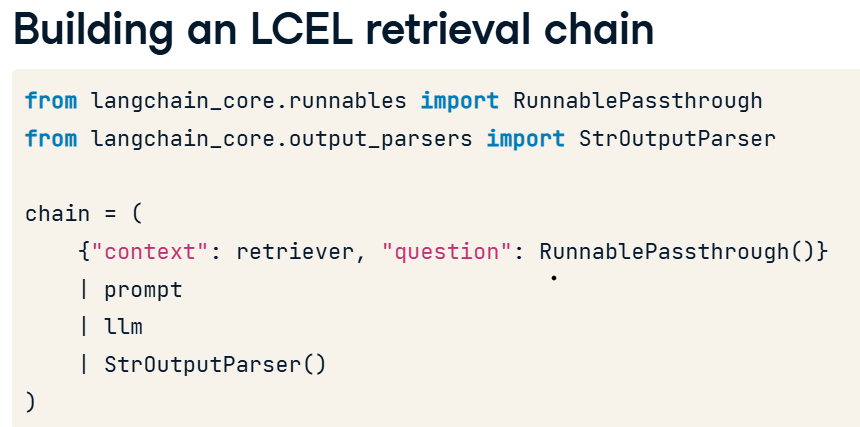
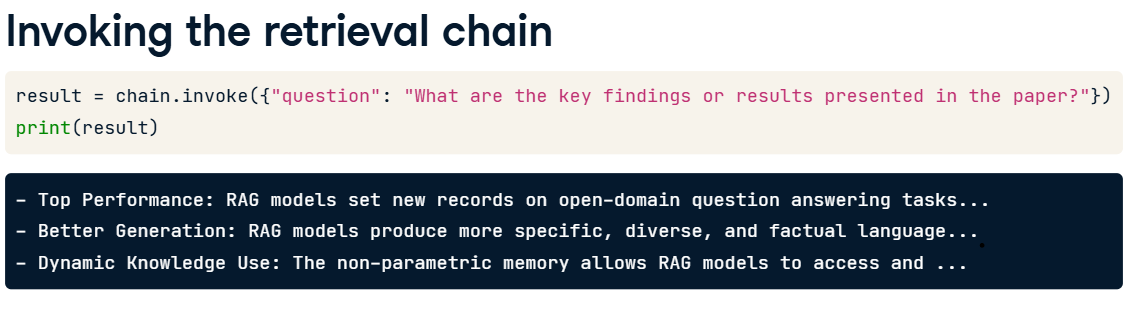

# Part 2: Improving the RAG architecture

## Loading and splitting the code files
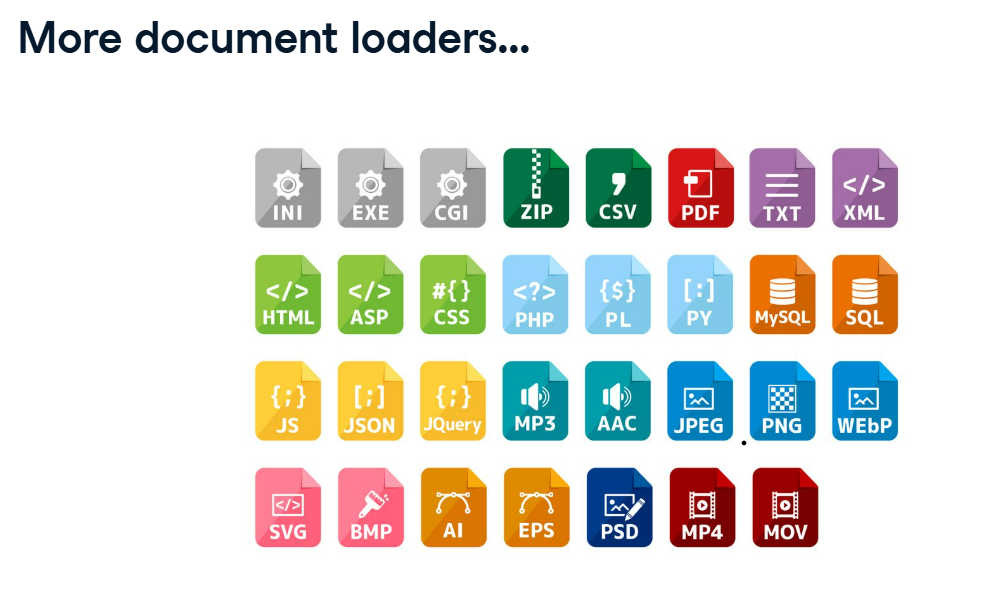

### Markdown file
Markdown is a lightweight markup language for creating formatted documents, and it's often the tool of choice for writing code documentation.
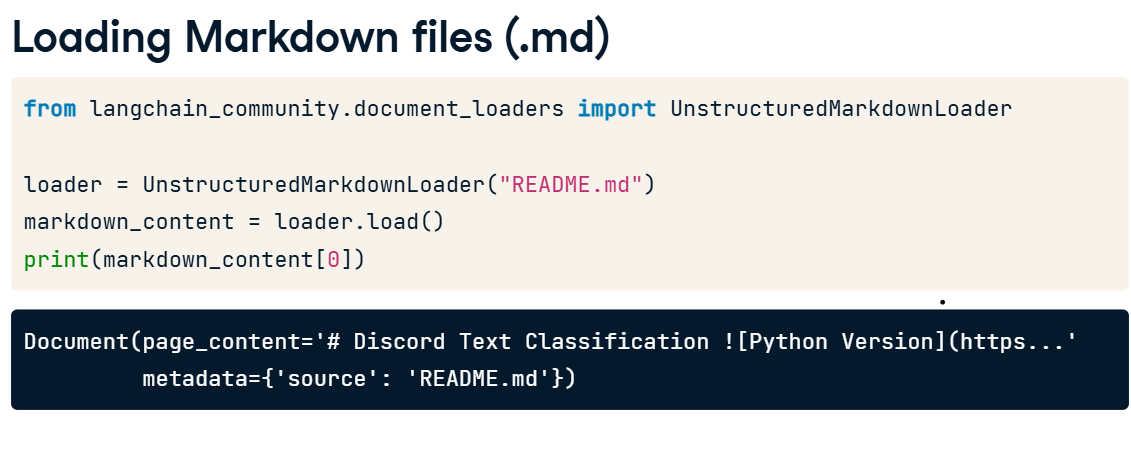

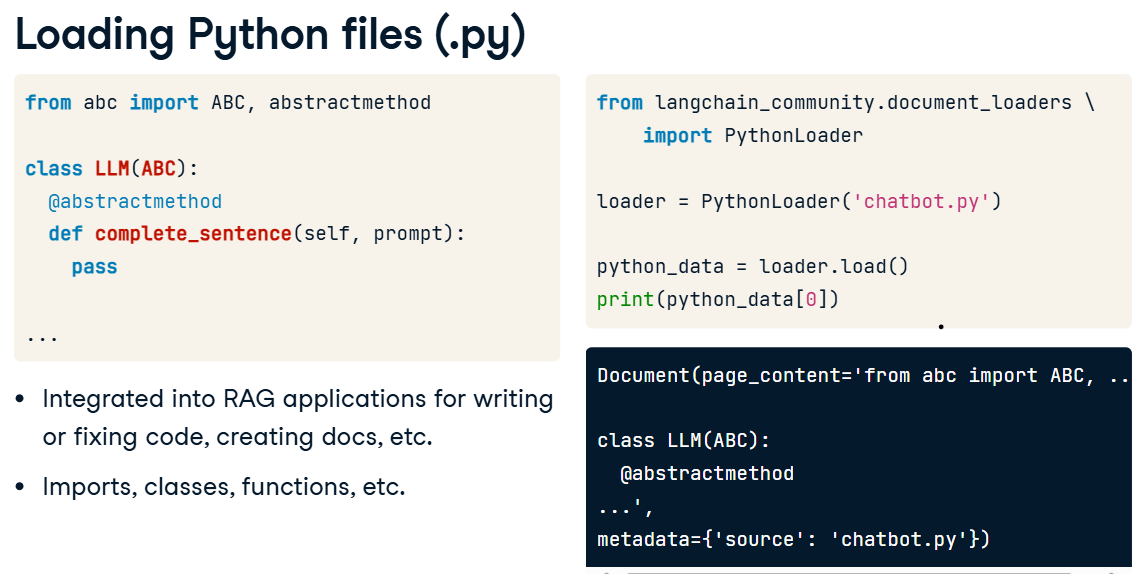

### splitting code files
When we are splitting the code files like python file, if we use the usual RecursiveCharacterTextSplitter only, it may fail to maintain the context because chunks are processed separately, key context has been lost. Our current strategy is naive because it doesn't consider structures like classes and functions.

So to avoid this problem, we use RecursiveCharacterTextSplitter but with .from_language() method.

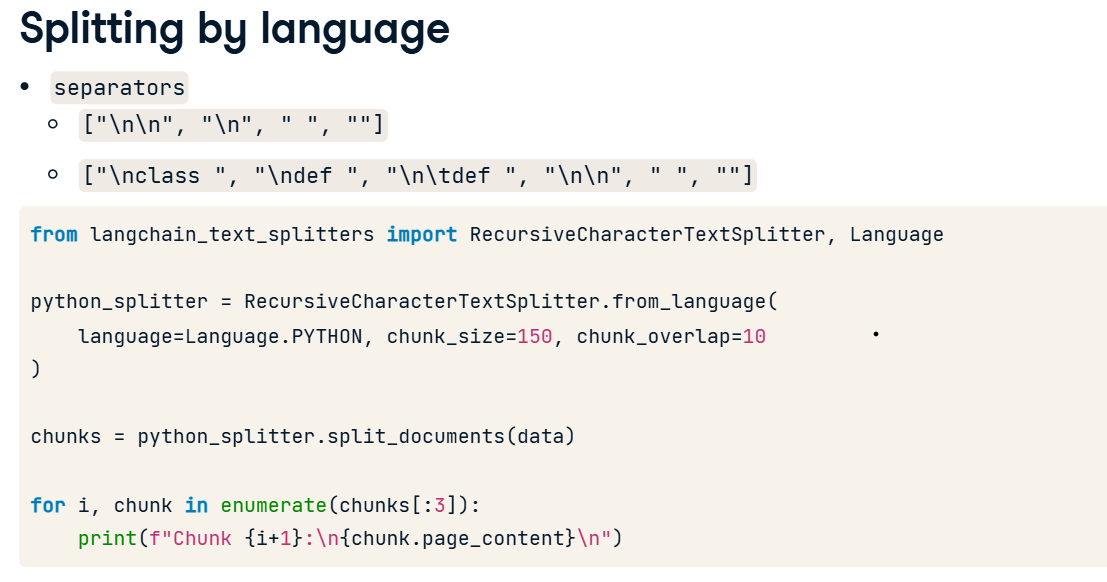

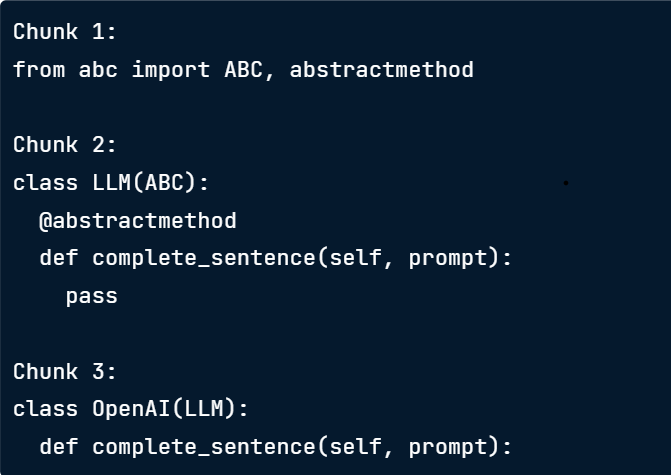

## Advanced Splitting methods
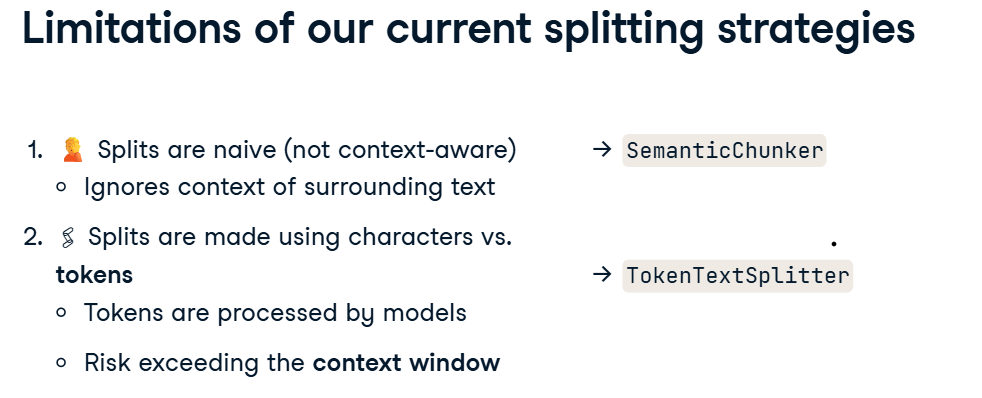

When we use a character text splitter with a chunk_size and chunk_overlap, we get chunks containing groups of characters that satisfy the chunking parameters.

When we split on tokens, the chunk_size and chunk_overlap refer to the number of tokens in the chunk, rather than characters, so a chunk_size of five means we can have a maximum of five tokens in the chunk.

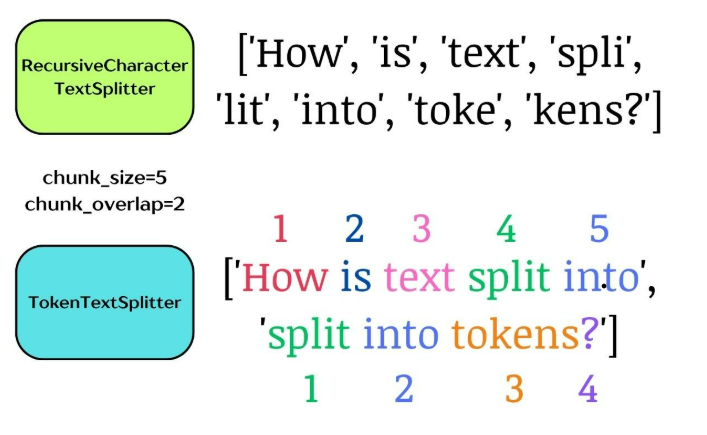

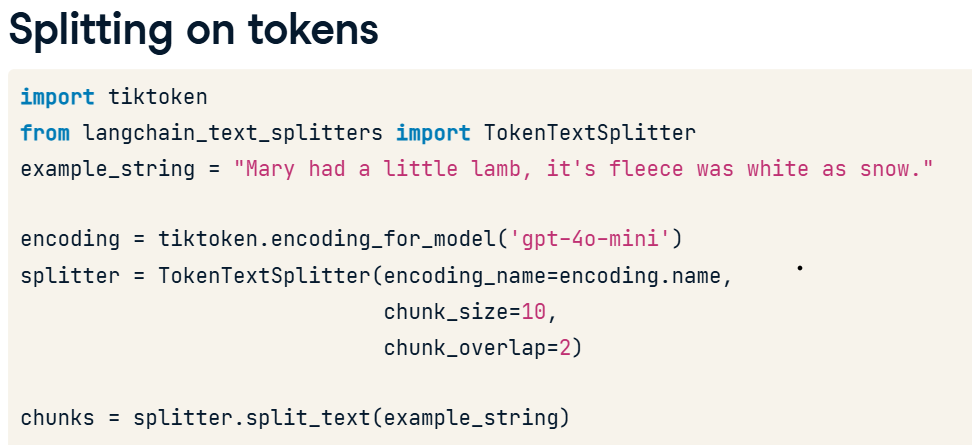

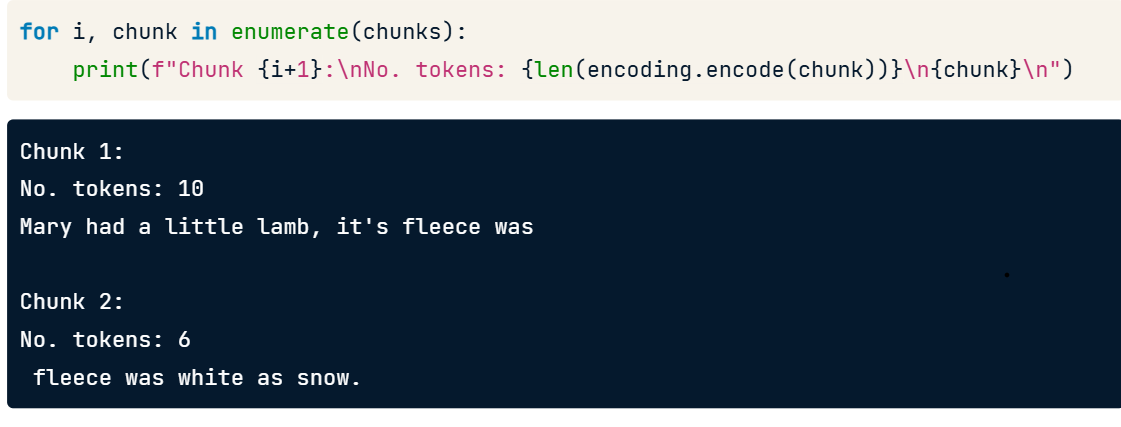

#### A character or token text splitter will split naively, which results in lost context. so we use semantic splitting
A semantic splitter will detect shifts in semantic meaning and perform the splits in those locations; in this example, when the discussion shifts from RAG to dogs.

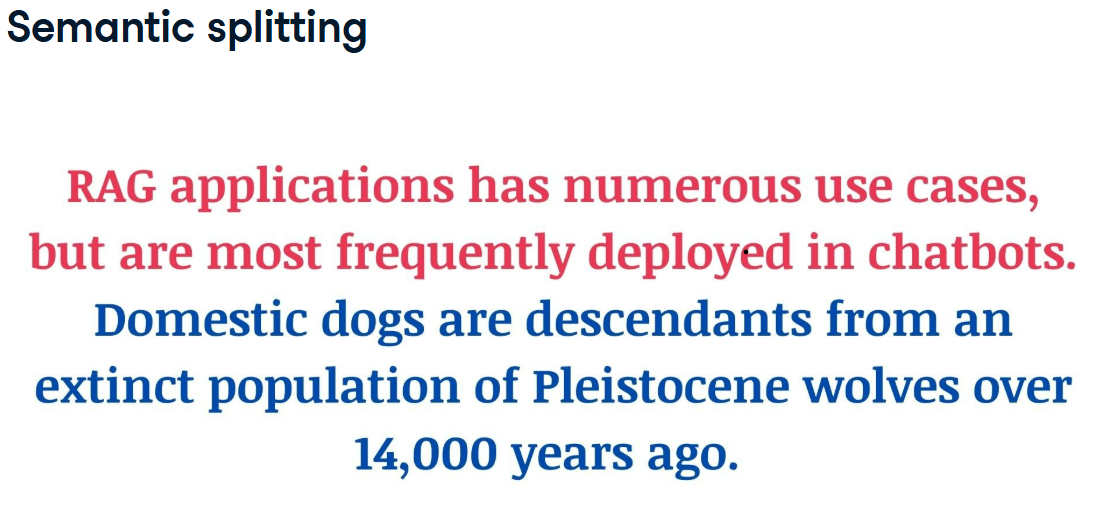

We pass two additional parameters: breakpoint_threshold_type, which sets the metric at which embeddings are compared, and breakpoint_threshold_amount, which sets the metric's threshold at which to perform the split.

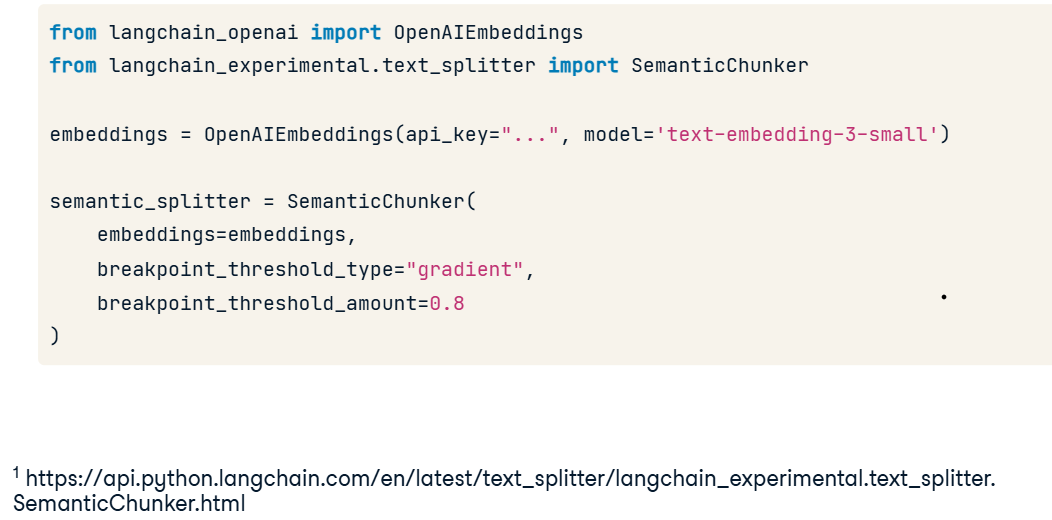

## Optimizing document retrieval
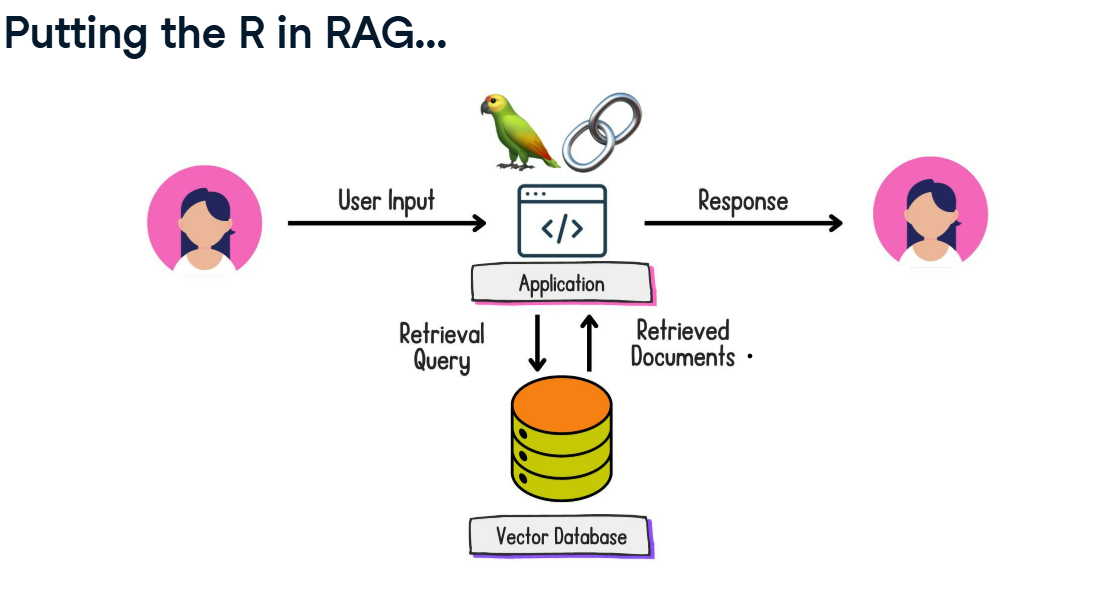

So far, our document retrieval has consisted of a vector database containing embedded documents. The input to the RAG application is then used to query the vectors, using a distance metric to determine which vectors are closest and therefore most similar and relevant. This type of retrieval is known as dense retrieval.

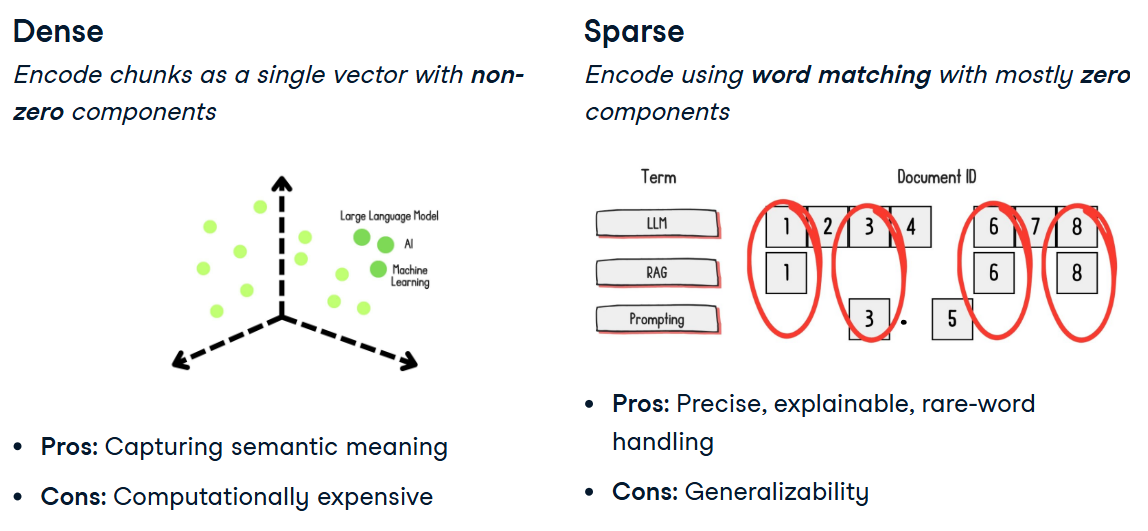

TF-IDF and BM25 are the two popular methods for encoding text as spare vectors. TF-IDF, or Term Frequency-Inverse Document Frequency, creates a sparse vector that measures a term's frequency in a document and rarity in other documents. This helps in identifying words that best represent the document's unique content. BM25, or best matching 25, is an improvement on TF-IDF that prevents high-frequency words from being over-emphasized in the encoding.

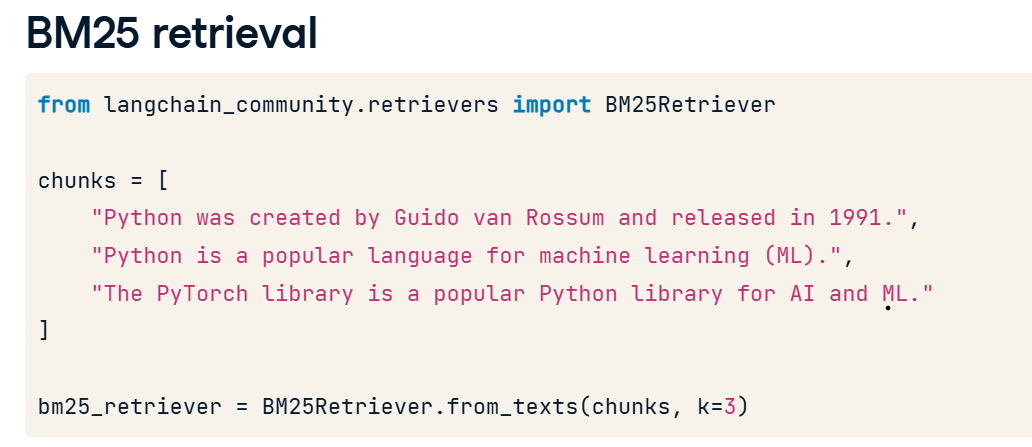

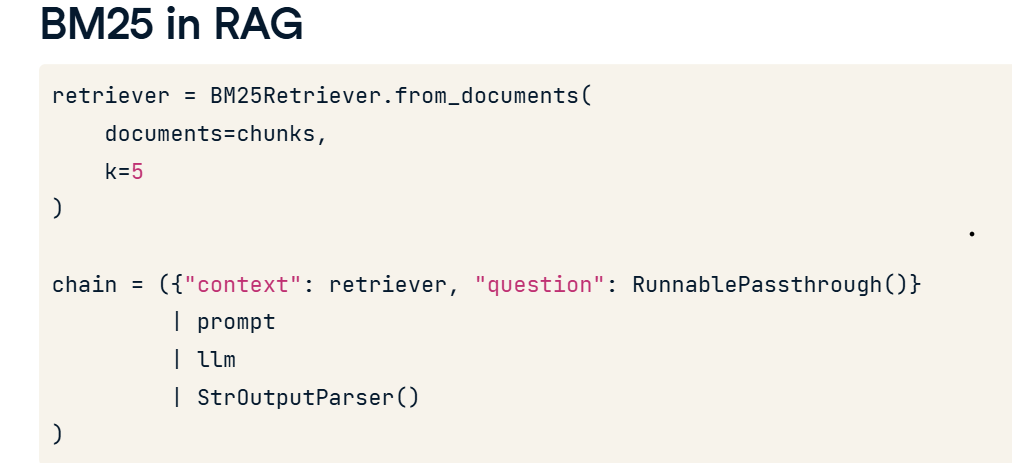